 UPSELL MODEL



1. Data Preprocessing

1.1 Raw Data Loading

In [44]:
# cust transaction
import pandas as pd

df_T = pd.read_csv("/content/5.CUSTTRXN.csv",encoding='latin1')

In [45]:
df_T.head()

,FORMAT,BILL_NO,CUSTOMER_ID,PRODUCT_DESCRIPTION,BILL_DATE,NSV,QTY,DISCOUNT
0,CP,CA8-CA801125-2001,EMP-0000002979,T-Shirt,08-03-2026,2100.00,3,0.00
1,CP,CA8-CA801125-2002,EMP-0000000149,Trouser,05-02-2026,3000.00,2,0.00
2,CP,CA8-CA801125-2003,EMP-0000004425,Jeans,23-03-2026,1894.55,1,105.45
3,CP,CA8-CA801125-2004,EMP-0000003215,Jeans,30-03-2026,1877.93,1,122.07
4,CP,CA8-CA801125-2005,EMP-0000002027,Trouser,30-03-2026,5238.01,4,761.99


In [46]:
# cust master
import pandas as pd

df_C = pd.read_csv("/content/5.CUSTDETAILS.csv",encoding='latin1')

In [47]:
df_C.head()

,CUSTOMER_ID,DOB,AGE,GENDER,CITY,REGION
0,EMP-0000000001,27-11-1979,47,F,THANE,West Zone
1,EMP-0000000002,10-05-1962,64,M,Satara,West Zone
2,EMP-0000000003,04-10-1974,52,M,THANE,West Zone
3,EMP-0000000004,19-03-1974,52,M,Jaipur,North Zone
4,EMP-0000000005,03-10-1992,34,M,Navi Mumbai,West Zone


1.2 Data Merging

In [48]:
import pandas as pd

In [49]:
df_T["CUSTOMER_ID"] = df_T["CUSTOMER_ID"].astype(str).str.strip()
df_C["CUSTOMER_ID"] = df_C["CUSTOMER_ID"].astype(str).str.strip()

df = pd.merge(df_T, df_C, on='CUSTOMER_ID', how='inner')

In [50]:
df.head()

,FORMAT,BILL_NO,CUSTOMER_ID,PRODUCT_DESCRIPTION,BILL_DATE,NSV,QTY,DISCOUNT,DOB,AGE,GENDER,CITY,REGION
0,CP,CA8-CA801125-2001,EMP-0000002979,T-Shirt,08-03-2026,2100.00,3,0.00,01-07-1986,40,M,Yevatmal,West Zone
1,CP,CA8-CA801125-2002,EMP-0000000149,Trouser,05-02-2026,3000.00,2,0.00,02-12-1978,48,M,Satara,West Zone
2,CP,CA8-CA801125-2003,EMP-0000004425,Jeans,23-03-2026,1894.55,1,105.45,05-12-1967,59,F,Muzaffarpur,East Zone
3,CP,CA8-CA801125-2004,EMP-0000003215,Jeans,30-03-2026,1877.93,1,122.07,16-11-1976,50,F,Muzaffarpur,East Zone
4,CP,CA8-CA801125-2005,EMP-0000002027,Trouser,30-03-2026,5238.01,4,761.99,11-03-1992,34,M,Siliguri,East Zone


In [51]:
df.shape

(30000, 13)

In [52]:
df.columns

Index(['FORMAT', 'BILL_NO', 'CUSTOMER_ID', 'PRODUCT_DESCRIPTION', 'BILL_DATE',
       'NSV', 'QTY', 'DISCOUNT', 'DOB', 'AGE', 'GENDER', 'CITY', 'REGION'],
      dtype='object')

In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   FORMAT               30000 non-null  object 
 1   BILL_NO              30000 non-null  object 
 2   CUSTOMER_ID          30000 non-null  object 
 3   PRODUCT_DESCRIPTION  30000 non-null  object 
 4   BILL_DATE            30000 non-null  object 
 5   NSV                  30000 non-null  float64
 6   QTY                  30000 non-null  int64  
 7   DISCOUNT             30000 non-null  float64
 8   DOB                  30000 non-null  object 
 9   AGE                  30000 non-null  int64  
 10  GENDER               30000 non-null  object 
 11  CITY                 30000 non-null  object 
 12  REGION               30000 non-null  object 
dtypes: float64(2), int64(2), object(9)
memory usage: 3.0+ MB


In [54]:
trans_ids = set(df_T["CUSTOMER_ID"])
cust_ids = set(df_C["CUSTOMER_ID"])

print("Transaction customers:", len(trans_ids))
print("Customer master:", len(cust_ids))

print("Common customers:", len(trans_ids & cust_ids))
print("Missing in master:", len(trans_ids - cust_ids))

Transaction customers: 3136
Customer master: 5000
Common customers: 3136
Missing in master: 0


1.3 Data Cleaning

In [55]:
(df['QTY'] <= 0).sum()

np.int64(0)

In [56]:
#negative/return/refund amount

refunds_df = df[df["QTY"] <= 0]

In [57]:
df = df[df["QTY"] > 0]

In [58]:
df.shape

(30000, 13)

In [59]:
df.isnull().sum()

,0
FORMAT,0
BILL_NO,0
CUSTOMER_ID,0
PRODUCT_DESCRIPTION,0
BILL_DATE,0
NSV,0
QTY,0
DISCOUNT,0
DOB,0
AGE,0


In [61]:
df = df.drop(columns=[ 'DOB','FORMAT','GENDER','CITY','REGION','AGE'])

In [62]:
# df['GENDER'] = df['GENDER'].fillna('Unknown')

In [63]:
#df['CITY'] = df['CITY'].fillna('Unknown')

In [64]:
#df['REGION'] = df['REGION'].fillna('Unknown')

In [65]:
# split columns
df['PRODUCT_DESCRIPTION'] = df['PRODUCT_DESCRIPTION'].str.split(', ')
df['BILL_NO'] = df['BILL_NO'].str.split(', ')

# explode
df = df.explode(['BILL_DATE', 'PRODUCT_DESCRIPTION', 'BILL_NO'])

# convert date
df['BILL_DATE'] = pd.to_datetime(df['BILL_DATE'], format='%d-%m-%Y')
df["BILL_DATE"] = pd.to_datetime(df["BILL_DATE"], dayfirst=True, errors="coerce")
df = df.dropna(subset=["BILL_DATE"])

# clean product names
df['PRODUCT_DESCRIPTION'] = df['PRODUCT_DESCRIPTION'].str.strip().str.title()

2. FEATURE BUILDING

2.1 Temporal Features : forward-looking modeling

In [66]:
df = df.sort_values(["CUSTOMER_ID", "BILL_DATE"])

# Previous purchase date
df["Previous Date"] = df.groupby("CUSTOMER_ID")[
    "BILL_DATE"
].shift(1)

# Days between purchases : customer purchase cadence
df["Gap Days"] = (
    df["BILL_DATE"] - df["Previous Date"]
).dt.days

df["Gap Days"] = df["Gap Days"].fillna(0)

2.2 Time-Based Split (Upsell Build Learning)

In [67]:
cutoff = df["BILL_DATE"].quantile(0.75)

In [68]:
cutoff

Timestamp('2026-03-08 00:00:00')

In [69]:
past_df = df[df["BILL_DATE"] <= cutoff]
future_df = df[df["BILL_DATE"] > cutoff]

In [70]:
print(past_df.columns.tolist())

['BILL_NO', 'CUSTOMER_ID', 'PRODUCT_DESCRIPTION', 'BILL_DATE', 'NSV', 'QTY', 'DISCOUNT', 'Previous Date', 'Gap Days']


*`Check Clean Data`*



In [71]:
df.columns

Index(['BILL_NO', 'CUSTOMER_ID', 'PRODUCT_DESCRIPTION', 'BILL_DATE', 'NSV',
       'QTY', 'DISCOUNT', 'Previous Date', 'Gap Days'],
      dtype='object')

In [72]:
df.head()

,BILL_NO,CUSTOMER_ID,PRODUCT_DESCRIPTION,BILL_DATE,NSV,QTY,DISCOUNT,Previous Date,Gap Days
20883,CA8-CA801125-22884,EMP-0000000001,T-Shirt,2026-01-01,1400.0,2,0.0,NaT,0.0
28187,CA8-CA801125-30188,EMP-0000000001,Trouser,2026-01-01,6000.0,4,0.0,2026-01-01,0.0
29737,CA8-CA801125-31738,EMP-0000000001,Jeans,2026-02-03,2000.0,1,0.0,2026-01-01,33.0
10073,CA8-CA801125-12074,EMP-0000000002,T-Shirt,2026-01-01,700.0,1,0.0,NaT,0.0
2634,CA8-CA801125-4635,EMP-0000000002,Trouser,2026-01-17,1500.0,1,0.0,2026-01-01,16.0


2.3 FEATURE ENGINEERING

In [73]:
def build_features(data):
  cust_df = data.groupby('CUSTOMER_ID').agg({
      'NSV': 'sum',
      'DISCOUNT': 'sum',
      'QTY': 'sum',
      'BILL_NO': 'nunique',
      'BILL_DATE': ['max', 'min'],
      'PRODUCT_DESCRIPTION':  "nunique",
      # 'GENDER': 'first',
      # 'CITY': 'first',
      # 'REGION': 'first',
      "Gap Days": "mean"


  }).reset_index()

  # Naming columns
  cust_df.columns = [
      'CUSTOMER_ID',
      'Total Spend',
      'Total Discount',
      'Total Qty',
      'Total Transactions',
      'Last Purchase',
      'First Purchase',
      "Unique_Categories",
      # 'Gender',
      # 'City',
      # 'Region',
      "Average Purchase Gap"

  ]

# RFM Build
  reference_date = past_df["BILL_DATE"].max()

  cust_df["Recency"] = (
    reference_date - cust_df["Last Purchase"]
  ).dt.days
  cust_df['Tenure'] = (reference_date - cust_df['First Purchase']).dt.days
  cust_df['Frequency'] = cust_df['Total Transactions']
  cust_df['Average Spend'] = cust_df['Total Spend'] / cust_df['Frequency']
  cust_df["Average Spend"] = cust_df["Average Spend"].fillna(0)

  return cust_df

features = build_features(past_df)

3. UPSELL

3.1 Upsell Build

In [74]:
# 1. FUTURE-BASED BUSINESS TARGET

from sklearn.preprocessing import MinMaxScaler

# Past product categories
past_cat = past_df.groupby(
    "CUSTOMER_ID"
)["PRODUCT_DESCRIPTION"].apply(set)


# 2. Future product categories
future_cat = future_df.groupby(
    "CUSTOMER_ID"
)["PRODUCT_DESCRIPTION"].apply(set)


# 3. Future spend
future_spend = future_df.groupby(
    "CUSTOMER_ID"
)["NSV"].sum()


# 4. Past spend
past_spend = past_df.groupby(
    "CUSTOMER_ID"
)["NSV"].sum()


# 5. Map spend into features table
features["Future_Spend"] = (
    features["CUSTOMER_ID"]
    .map(future_spend)
    .fillna(0)
)

features["Past_Spend"] = (
    features["CUSTOMER_ID"]
    .map(past_spend)
    .fillna(0)
)


# 6. Spend Growth %
features["Spend_Growth"] = (
    (
        features["Future_Spend"]
        - features["Past_Spend"]
    )
    /
    (features["Past_Spend"] + 1)
)


# 7. Count NEW categories purchased (in future period)
features["New_Category_Count"] = (
    features["CUSTOMER_ID"]
    .apply(
        lambda x: len(
            future_cat.get(x, set())
            -
            past_cat.get(x, set())
        )
    )
)


# 8. HYBRID BUSINESS UPSELL SCORE

scaler = MinMaxScaler()

# Normalize spend growth
features["Growth_Score"] = scaler.fit_transform(
    features[["Spend_Growth"]]
)

# Normalize category expansion
features["Category_Score"] = scaler.fit_transform(
    features[["New_Category_Count"]]
)

# Weighted hybrid score
features["Upsell_Score"] = (
    0.7 * features["Growth_Score"]
    +
    0.3 * features["Category_Score"]
)


# 9. Top 25% customers = Upsell
threshold = features[
    "Upsell_Score"
].quantile(0.75)

features["Upsell"] = (
    features["Upsell_Score"]
    >= threshold
).astype(int)


# 10. Discount Ratio %

features["Discount_Ratio"] = (
    features["Total Discount"]
    /
    (features["Total Spend"] + 1)
)


3.2 Remove excess features

In [75]:
# REMOVE FUTURE INFORMATION
features = features.drop(columns=[
    "Future_Spend",
    "Past_Spend",
    "Spend_Growth",
    "New_Category_Count",
    "Growth_Score",
    "Category_Score",
    "Upsell_Score"
], errors="ignore")

In [76]:
features["Upsell"].value_counts(normalize=True)

,proportion
Upsell,
0,0.749916
1,0.250084


3.3 Correlation

In [77]:
features.corr(numeric_only=True)['Upsell'].sort_values(ascending=False)

,Upsell
Upsell,1.000000
Recency,0.124942
Average Purchase Gap,0.050313
Discount_Ratio,-0.003300
Average Spend,-0.020055
Tenure,-0.099440
Total Spend,-0.100453
Total Discount,-0.100469
Total Qty,-0.101833
Total Transactions,-0.102644


In [78]:
features.corr(numeric_only=True)

,Total Spend,Total Discount,Total Qty,Total Transactions,Unique_Categories,Average Purchase Gap,Recency,Tenure,Frequency,Average Spend,Upsell,Discount_Ratio
Total Spend,1.000000,0.979001,0.998893,0.996379,0.284121,-0.109867,-0.189127,0.187999,0.996379,0.048360,-0.100453,-0.009060
Total Discount,0.979001,1.000000,0.979610,0.977575,0.275322,-0.105990,-0.182203,0.181046,0.977575,0.035554,-0.100469,0.099490
Total Qty,0.998893,0.979610,1.000000,0.997853,0.287145,-0.110531,-0.190797,0.189948,0.997853,0.033725,-0.101833,-0.005894
Total Transactions,0.996379,0.977575,0.997853,1.000000,0.291916,-0.112372,-0.194558,0.192736,1.000000,0.005599,-0.102644,-0.005538
Unique_Categories,0.284121,0.275322,0.287145,0.291916,1.000000,0.157475,-0.558540,0.563185,0.291916,0.005542,-0.267194,-0.009044
Average Purchase Gap,-0.109867,-0.105990,-0.110531,-0.112372,0.157475,1.000000,-0.356694,0.362000,-0.112372,-0.003635,0.050313,0.011365
Recency,-0.189127,-0.182203,-0.190797,-0.194558,-0.558540,-0.356694,1.000000,0.044508,-0.194558,0.016778,0.124942,0.013054
Tenure,0.187999,0.181046,0.189948,0.192736,0.563185,0.362000,0.044508,1.000000,0.192736,0.030010,-0.099440,-0.000198
Frequency,0.996379,0.977575,0.997853,1.000000,0.291916,-0.112372,-0.194558,0.192736,1.000000,0.005599,-0.102644,-0.005538
Average Spend,0.048360,0.035554,0.033725,0.005599,0.005542,-0.003635,0.016778,0.030010,0.005599,1.000000,-0.020055,-0.082938


*Saving Clean Data*

In [79]:
features.head()

,CUSTOMER_ID,Total Spend,Total Discount,Total Qty,Total Transactions,Last Purchase,First Purchase,Unique_Categories,Average Purchase Gap,Recency,Tenure,Frequency,Average Spend,Upsell,Discount_Ratio
0,EMP-0000000001,9400.00,0.00,7,3,2026-02-03,2026-01-01,3,11.000000,33,66,3,3133.333333,0,0.000000
1,EMP-0000000002,10042.28,157.72,10,7,2026-02-14,2026-01-01,2,6.285714,22,66,7,1434.611429,0,0.015704
2,EMP-0000000004,10102.75,97.25,7,4,2026-02-08,2026-01-17,3,5.500000,28,50,4,2525.687500,0,0.009625
3,EMP-0000000007,12883.94,116.06,8,6,2026-03-01,2026-01-26,3,5.666667,7,41,6,2147.323333,0,0.009007
4,EMP-0000000009,56648.15,951.85,47,22,2026-03-06,2026-01-02,4,2.863636,2,65,22,2574.915909,0,0.016803


In [80]:
features.shape

(2979, 15)

In [81]:
features.describe()

,Total Spend,Total Discount,Total Qty,Total Transactions,Last Purchase,First Purchase,Unique_Categories,Average Purchase Gap,Recency,Tenure,Frequency,Average Spend,Upsell,Discount_Ratio
count,2.979000e+03,2979.000000,2979.000000,2979.000000,2979,2979,2979.000000,2979.000000,2979.000000,2979.000000,2979.000000,2979.000000,2979.000000,2979.000000
mean,1.659146e+04,503.341339,13.102719,7.608593,2026-02-18 18:49:11.057401856,2026-01-18 03:32:41.329305088,2.412219,6.441376,17.215844,48.852299,7.608593,2159.991159,0.250084,0.031502
min,5.954700e+02,0.000000,1.000000,1.000000,2026-01-01 00:00:00,2026-01-01 00:00:00,1.000000,0.000000,0.000000,0.000000,1.000000,595.470000,0.000000,0.000000
25%,2.900000e+03,0.000000,2.000000,2.000000,2026-02-09 00:00:00,2026-01-04 00:00:00,1.000000,0.500000,3.000000,40.000000,2.000000,1489.991500,0.000000,0.000000
50%,6.929770e+03,167.140000,5.000000,3.000000,2026-02-25 00:00:00,2026-01-12 00:00:00,2.000000,5.500000,11.000000,55.000000,3.000000,2000.000000,0.000000,0.020976
75%,1.481788e+04,494.000000,12.000000,7.000000,2026-03-05 00:00:00,2026-01-27 00:00:00,3.000000,9.666667,27.000000,63.000000,7.000000,2532.267313,0.500000,0.047915
max,1.759573e+06,57727.450000,1375.000000,785.000000,2026-03-08 00:00:00,2026-03-08 00:00:00,4.000000,32.000000,66.000000,66.000000,785.000000,10000.000000,1.000000,0.175545
std,5.720149e+04,1809.534140,44.738898,25.381029,NaN,NaN,1.146401,6.093447,17.232657,17.346593,25.381029,1104.828441,0.433134,0.037371


In [ ]:
features.to_csv("CLEAN_Dataset.csv", index=False)

4. ENCODING & TRAIN-TEST

4.1 Encoding

In [ ]:
selected_features = [
    'Recency',
    'Average Purchase Gap',
    'Unique_Categories',
    'Discount_Ratio'
]

X = features[selected_features]

y = features["Upsell"]

In [ ]:
X = X.fillna(0)

In [ ]:
X.columns

Index(['Recency', 'Average Purchase Gap', 'Unique_Categories',
       'Discount_Ratio'],
      dtype='object')

In [ ]:
X.head()

,Recency,Average Purchase Gap,Unique_Categories,Discount_Ratio
0,2,1.0,2,0.393234
1,3,0.0,4,0.349821
2,10,0.0,1,0.133875
3,1,0.0,2,0.378197
4,3,0.0,1,0.349428


In [ ]:
#check multicolinearity
corr_matrix = X.corr().abs()

high_corr = []

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if corr_matrix.iloc[i, j] > 0.85:
            high_corr.append((
                corr_matrix.columns[i],
                corr_matrix.columns[j],
                corr_matrix.iloc[i, j]
            ))

high_corr

[]

4.2 Group Shuffle Split

In [ ]:
from sklearn.model_selection import GroupShuffleSplit

splitter = GroupShuffleSplit(
    test_size=0.3,
    random_state=42
)

train_idx, test_idx = next(
    splitter.split(X, y, groups=features["CUSTOMER_ID"])
)

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

In [ ]:
print(X_train.shape)
print(X_test.shape)

(5433, 4)
(2329, 4)


5. MODEL TRAINING & EVALUATION

5.1 Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=3,
    min_samples_leaf=20,
    class_weight="balanced",
    random_state=42
)

rf_model.fit(X_train, y_train)

features["Upsell_Probability"] = (
    rf_model.predict_proba(X)[:, 1]
)

features["Predicted_Upsell"] = (
   features["Upsell_Probability"] >= 0.6
).astype(int)

5.2 Evaluation

In [ ]:
from sklearn.metrics import accuracy_score

import numpy as np

y_prob = rf_model.predict_proba(X_test)[:, 1]
y_pred = np.where(y_prob > 0.6, 1, 0)

In [ ]:
accuracy_score(y_test, y_pred)

0.7067410905968227

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score

print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print(classification_report(y_test, y_pred))


ROC-AUC: 0.7827778112631346
              precision    recall  f1-score   support

           0       0.93      0.66      0.77      1765
           1       0.44      0.85      0.58       564

    accuracy                           0.71      2329
   macro avg       0.69      0.75      0.68      2329
weighted avg       0.81      0.71      0.73      2329



In [ ]:
from sklearn.model_selection import GroupKFold, cross_val_score

group_kfold = GroupKFold(n_splits=5)

cv_scores = cross_val_score(
    rf_model,
    X,
    y,
    cv=group_kfold,
    groups=features["CUSTOMER_ID"],
    scoring="roc_auc"
)

print("Group CV ROC-AUC:", cv_scores.mean())

Group CV ROC-AUC: 0.7826564687802906


5.3 Feature Importance

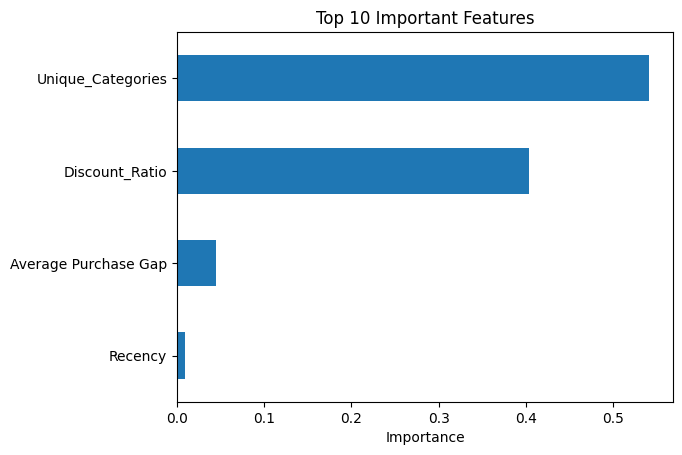

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.Series(rf_model.feature_importances_, index=X.columns)
feature_importance = feature_importance.sort_values(ascending=False)

feature_importance.head(10).sort_values().plot(kind='barh')

plt.title("Top 10 Important Features")
plt.xlabel("Importance")
plt.show()

In [ ]:
feature_importance.head(15)

,0
Unique_Categories,0.541541
Discount_Ratio,0.404038
Average Purchase Gap,0.045306
Recency,0.009116


5.4 Matrices & Graphs

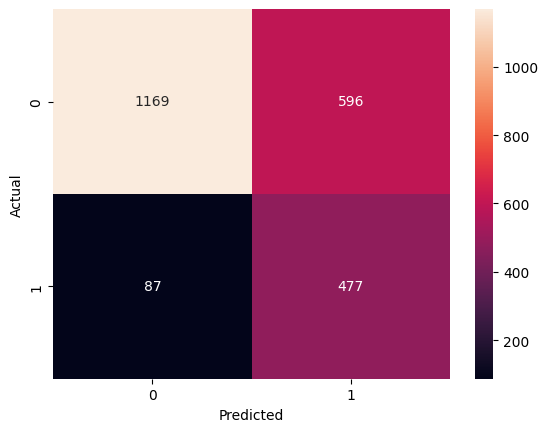

In [ ]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
print(confusion_matrix(y_test, y_pred))

[[1169  596]
 [  87  477]]


                       Recency  Average Purchase Gap  Unique_Categories  \
Recency               1.000000             -0.150939          -0.059834   
Average Purchase Gap -0.150939              1.000000           0.121487   
Unique_Categories    -0.059834              0.121487           1.000000   
Discount_Ratio        0.026922             -0.018500           0.269781   

                      Discount_Ratio  
Recency                     0.026922  
Average Purchase Gap       -0.018500  
Unique_Categories           0.269781  
Discount_Ratio              1.000000  


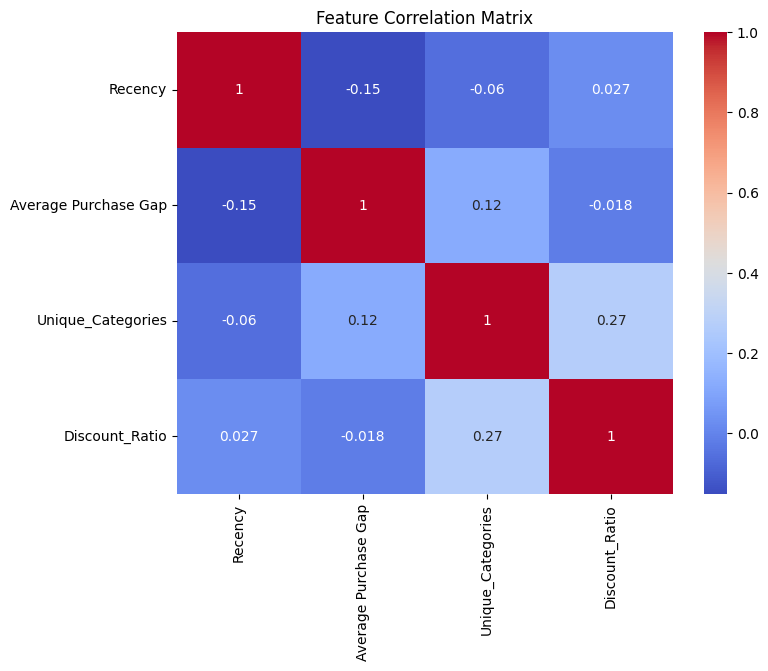

In [ ]:
# Correlation matrix
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = X.corr()

print(corr_matrix)

# Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()

In [ ]:
features["Upsell"].value_counts()

,count
Upsell,
0,5782
1,1980


In [ ]:
features["Upsell"].value_counts(normalize=True)

,proportion
Upsell,
0,0.744911
1,0.255089


In [ ]:
print(features["Predicted_Upsell"].value_counts())
features["Predicted_Upsell"].value_counts(normalize=True)

Predicted_Upsell
0    4221
1    3541
Name: count, dtype: int64


,proportion
Predicted_Upsell,
0,0.543803
1,0.456197
